# Healthcare Clinic Appointment Dataset


## TASK:1 Data Preparation and Exploratory Data Analysis


In [2]:
# 1. Data Profiling
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('Multi-Location Healthcare Clinic Revenue Dataset.csv')

# Basic Profiling
print('Shape:', df.shape)
display(df.head())

# # Data types, non-null values
print("\nData types and non-null values:", df.info())

# Summary Statistics
display(df.describe(include ='all').T)

Shape: (30000, 12)


,appointment_id,patient_id,clinic_id,doctor_id,specialty,appointment_date,booking_lead_time_days,appointment_time_slot,no_show_flag,cancellation_flag,revenue_expected,revenue_realized
0,1,4572,5,27,Dermatology,2024-07-04,8,Evening,0,0,941,941
1,2,126,2,8,ENT,2024-04-09,12,Afternoon,1,0,1123,0
2,3,2314,4,28,Pediatrics,2024-04-29,7,Morning,0,0,749,749
3,4,3318,5,28,ENT,2024-12-16,27,Morning,0,0,684,684
4,5,2569,6,5,General Medicine,2024-04-28,10,Morning,0,1,744,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   appointment_id          30000 non-null  int64 
 1   patient_id              30000 non-null  int64 
 2   clinic_id               30000 non-null  int64 
 3   doctor_id               30000 non-null  int64 
 4   specialty               30000 non-null  object
 5   appointment_date        30000 non-null  object
 6   booking_lead_time_days  30000 non-null  int64 
 7   appointment_time_slot   30000 non-null  object
 8   no_show_flag            30000 non-null  int64 
 9   cancellation_flag       30000 non-null  int64 
 10  revenue_expected        30000 non-null  int64 
 11  revenue_realized        30000 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 2.7+ MB

Data types and non-null values: None


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
appointment_id,30000.0,NaN,NaN,NaN,15000.5,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
patient_id,30000.0,NaN,NaN,NaN,2499.8225,1449.119106,1.0,1241.0,2504.0,3754.0,5000.0
clinic_id,30000.0,NaN,NaN,NaN,4.5108,2.282248,1.0,3.0,5.0,7.0,8.0
doctor_id,30000.0,NaN,NaN,NaN,20.409067,11.520293,1.0,11.0,20.0,30.0,40.0
specialty,30000,6,Orthopedics,5047,NaN,NaN,NaN,NaN,NaN,NaN,NaN
appointment_date,30000,365,2024-04-11,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
booking_lead_time_days,30000.0,NaN,NaN,NaN,14.5312,8.679228,0.0,7.0,15.0,22.0,29.0
appointment_time_slot,30000,3,Morning,10097,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_show_flag,30000.0,NaN,NaN,NaN,0.16,0.366612,0.0,0.0,0.0,0.0,1.0
cancellation_flag,30000.0,NaN,NaN,NaN,0.0828,0.275584,0.0,0.0,0.0,0.0,1.0


In [3]:
# Target Variable

print("Target Variable:", "no_show_flag")
print("0 = Attended")
print("1 = No-show")

print("\nTarget Distribution:")
print(df['no_show_flag'].value_counts())


Target Variable: no_show_flag
0 = Attended
1 = No-show

Target Distribution:
no_show_flag
0    25200
1     4800
Name: count, dtype: int64


In [4]:
# 2: Check Data Quality / Find Inconsistencies

# Missing values
print('Missing values:\n', df.isnull().sum())

# Duplicate rows
print('\n Duplicate Rows:', df.duplicated().sum())

# Duplicate appointment IDs check
print('Duplicate appointment IDs:', df['appointment_id'].duplicated().sum())

# Unique categorical values check
for col in [
    'specialty',
    'appointment_time_slot',
    'no_show_flag',
    'cancellation_flag']:
    print(f'\n{col}:')
    print(df[col].unique())

# Negative Values
numeric_cols = ['booking_lead_time_days','revenue_expected','revenue_realized']

print("\nNegative values:")
print((df[numeric_cols]< 0).sum())

#Logical consistency check (Realised revenue greater than expected)
print('\n Realised revenue > expected revenue count:',
    (df['revenue_realized'] > df['revenue_expected']).sum(),
)


Missing values:
 appointment_id            0
patient_id                0
clinic_id                 0
doctor_id                 0
specialty                 0
appointment_date          0
booking_lead_time_days    0
appointment_time_slot     0
no_show_flag              0
cancellation_flag         0
revenue_expected          0
revenue_realized          0
dtype: int64

 Duplicate Rows: 0
Duplicate appointment IDs: 0

specialty:
['Dermatology' 'ENT' 'Pediatrics' 'General Medicine' 'Cardiology'
 'Orthopedics']

appointment_time_slot:
['Evening' 'Afternoon' 'Morning']

no_show_flag:
[0 1]

cancellation_flag:
[0 1]

Negative values:
booking_lead_time_days    0
revenue_expected          0
revenue_realized          0
dtype: int64

 Realised revenue > expected revenue count: 0



booking_lead_time_days
Lower bound: -15.5
Upper bound: 44.5
Number of outliers: 0

revenue_expected
Lower bound: -146.0
Upper bound: 1654.0
Number of outliers: 0

revenue_realized
Lower bound: -559.0
Upper bound: 1793.0
Number of outliers: 0


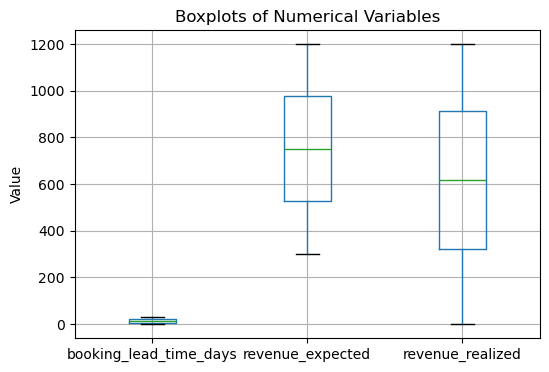

In [5]:
# Outlier Detection using Interquartile Range (IQR) method
numeric_cols = ['booking_lead_time_days','revenue_expected','revenue_realized']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\n{col}")
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of outliers:", len(outliers))

# VVisualize outlierswith boxplots
df[numeric_cols].boxplot(figsize=(6,4))
plt.title("Boxplots of Numerical Variables")
plt.ylabel("Value")
plt.show()

In [6]:
# 3. Clean the Data

# Convert appointment_date to datetime
df['appointment_date'] = pd.to_datetime(df['appointment_date'],format="%Y-%m-%d")

## Appointment Date Range
print(f"Appointment Date Range: {df['appointment_date'].min().date()} - {df['appointment_date'].max().date()}")

Appointment Date Range: 2024-01-01 - 2024-12-30


In [7]:
# 4.Verify Clean Data 

# Check the conversion
print(df["appointment_date"].dtype)
print("Start:", df["appointment_date"].min())
print("End:", df["appointment_date"].max())

datetime64[ns]
Start: 2024-01-01 00:00:00
End: 2024-12-30 00:00:00


In [8]:
# 5. Identify Encoding Requirements

categorical_cols = ['specialty', 'appointment_time_slot']
for col in categorical_cols:
  print(f'\n{col} value counts:\n', df[col].value_counts())

# Demonstrate One-Hot Encoding
encoded_df = pd.get_dummies(df, columns = categorical_cols, drop_first = True, dtype = int)
print("\n Original shape:", df.shape)
print("Encoded shape:", encoded_df.shape)
display(encoded_df.head())


specialty value counts:
 specialty
Orthopedics         5047
General Medicine    5043
Cardiology          5021
Dermatology         4995
ENT                 4992
Pediatrics          4902
Name: count, dtype: int64

appointment_time_slot value counts:
 appointment_time_slot
Morning      10097
Evening      10049
Afternoon     9854
Name: count, dtype: int64

 Original shape: (30000, 12)
Encoded shape: (30000, 17)


,appointment_id,patient_id,clinic_id,doctor_id,appointment_date,booking_lead_time_days,no_show_flag,cancellation_flag,revenue_expected,revenue_realized,specialty_Dermatology,specialty_ENT,specialty_General Medicine,specialty_Orthopedics,specialty_Pediatrics,appointment_time_slot_Evening,appointment_time_slot_Morning
0,1,4572,5,27,2024-07-04,8,0,0,941,941,1,0,0,0,0,1,0
1,2,126,2,8,2024-04-09,12,1,0,1123,0,0,1,0,0,0,0,0
2,3,2314,4,28,2024-04-29,7,0,0,749,749,0,0,0,0,1,0,1
3,4,3318,5,28,2024-12-16,27,0,0,684,684,0,1,0,0,0,0,1
4,5,2569,6,5,2024-04-28,10,0,1,744,0,0,0,1,0,0,0,1


### Exploratory Data Analysis (EDA) & Visualization


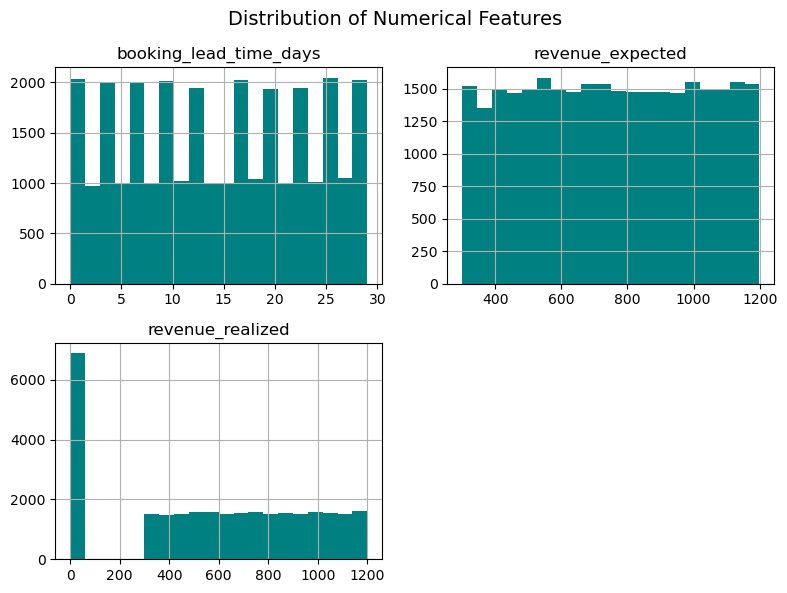

In [9]:
# 1. Numerical distributions
df[['booking_lead_time_days', 'revenue_expected','revenue_realized']].hist(figsize=(8,6),bins=20, color='teal')
plt.suptitle('Distribution of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

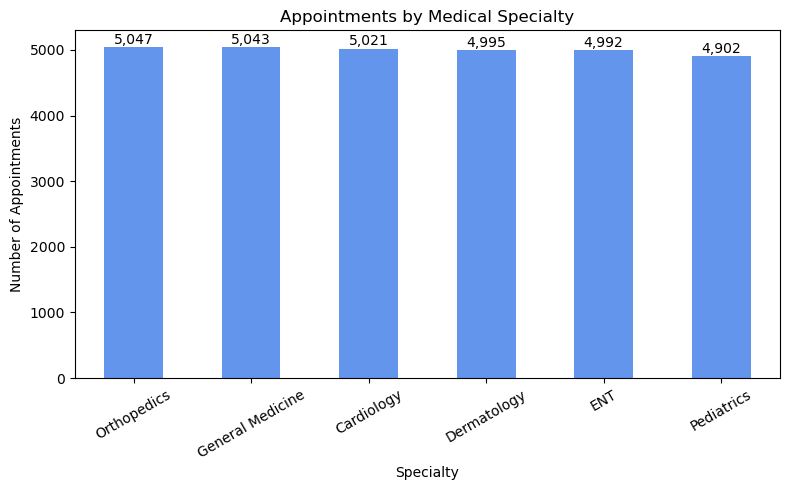

In [10]:
# 2. Appointments by specialty
plt.figure(figsize=(8, 5))

counts = df['specialty'].value_counts()

ax = counts.plot(
    kind='bar',
    color='cornflowerblue'
)

plt.title('Appointments by Medical Specialty')
plt.xlabel('Specialty')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=30)

# Add counts above each bar
for i, count in enumerate(counts):
    ax.text(
        i,
        count + 50,
        f'{count:,}',
        ha='center'
    )

plt.tight_layout()
plt.show()

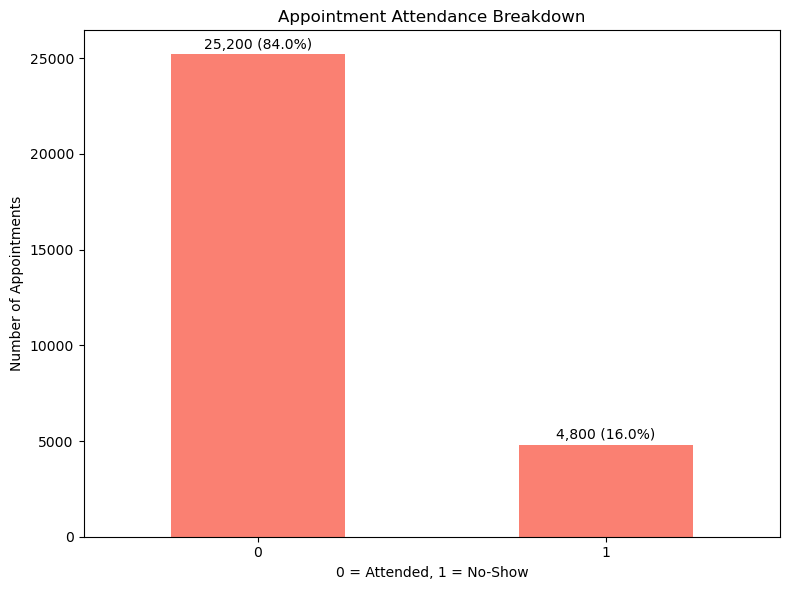

In [11]:
# 3. No-Show Distribution
counts = df['no_show_flag'].value_counts().sort_index()
percentages = counts / len(df) * 100

plt.figure(figsize=(8, 6))
ax = counts.plot(
    kind='bar',
    color='salmon'
)

plt.title('Appointment Attendance Breakdown')
plt.xlabel('0 = Attended, 1 = No-Show')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=0)

# Add count and percentage labels
for i, (count, percentage) in enumerate(zip(counts, percentages)):
    ax.text(
        i,
        count + 300,
        f'{count:,} ({percentage:.1f}%)',
        ha='center'
    )

plt.tight_layout()
plt.show()

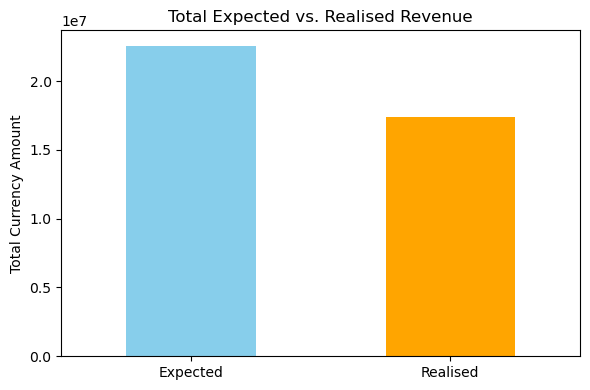


Revenue Summary:
Expected Revenue: 22,555,543
Realised Revenue: 17,382,830
Difference: 5,172,713
Difference as % of Expected Revenue: 22.93%


In [12]:
# 4. Expected vs Realized Revenue Comparison
plt.figure(figsize=(6, 4))

revenue_totals = df[['revenue_expected', 'revenue_realized']].sum()
revenue_totals.plot(kind='bar', color=['skyblue', 'orange'])

plt.title('Total Expected vs. Realised Revenue')
plt.ylabel('Total Currency Amount')
plt.xticks([0, 1], ['Expected', 'Realised'], rotation=0)

plt.tight_layout()
plt.show()

# Revenue summary
expected = revenue_totals['revenue_expected']
realized = revenue_totals['revenue_realized']
difference = expected - realized
shortfall_pct = (difference / expected) * 100

print("\nRevenue Summary:")
print(f"Expected Revenue: {expected:,.0f}")
print(f"Realised Revenue: {realized:,.0f}")
print(f"Difference: {difference:,.0f}")
print(f"Difference as % of Expected Revenue: {shortfall_pct:.2f}%")

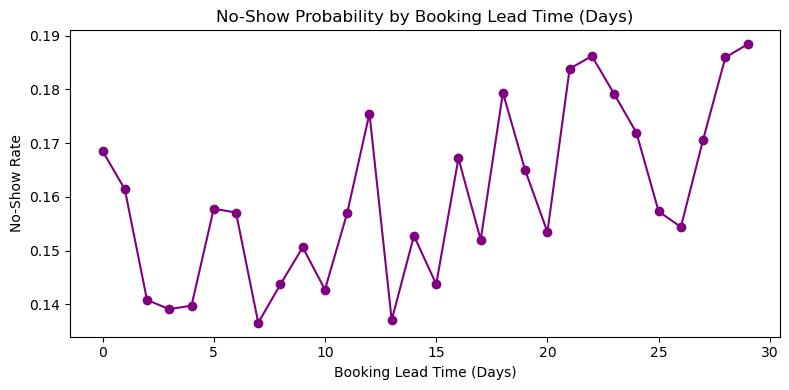


No-Show Rate by Booking Lead Time:
0 days: 16.9% | 1 days: 16.1% | 2 days: 14.1% | 3 days: 13.9% | 4 days: 14.0% | 5 days: 15.8% | 6 days: 15.7% | 7 days: 13.7% | 8 days: 14.4% | 9 days: 15.1% | 10 days: 14.3% | 11 days: 15.7% | 12 days: 17.5% | 13 days: 13.7% | 14 days: 15.3%
15 days: 14.4% | 16 days: 16.7% | 17 days: 15.2% | 18 days: 17.9% | 19 days: 16.5% | 20 days: 15.3% | 21 days: 18.4% | 22 days: 18.6% | 23 days: 17.9% | 24 days: 17.2% | 25 days: 15.7% | 26 days: 15.4% | 27 days: 17.1% | 28 days: 18.6% | 29 days: 18.8%


In [13]:
# 5. No-Show Rate by Booking Lead Time (
plt.figure(figsize=(8, 4))
lead_time_noshow = df.groupby('booking_lead_time_days')['no_show_flag'].mean()
lead_time_noshow.plot(kind='line', marker='o', color='purple')
plt.title('No-Show Probability by Booking Lead Time (Days)')
plt.xlabel('Booking Lead Time (Days)')
plt.ylabel('No-Show Rate')
plt.tight_layout()
plt.show()

print("\nNo-Show Rate by Booking Lead Time:")

items = [
    f"{days} days: {rate * 100:.1f}%"
    for days, rate in lead_time_noshow.items()
]

print(" | ".join(items[:15]))
print(" | ".join(items[15:]))

           revenue_expected  revenue_realized revenue_shortfall_pct
clinic_id                                                          
1                   2731073           2092168                23.39%
2                   2839519           2215009                21.99%
3                   2782925           2136896                23.21%
4                   2899792           2256288                22.19%
5                   2891480           2189651                24.27%
6                   2741189           2130240                22.29%
7                   2839697           2183377                23.11%
8                   2829868           2179201                22.99%


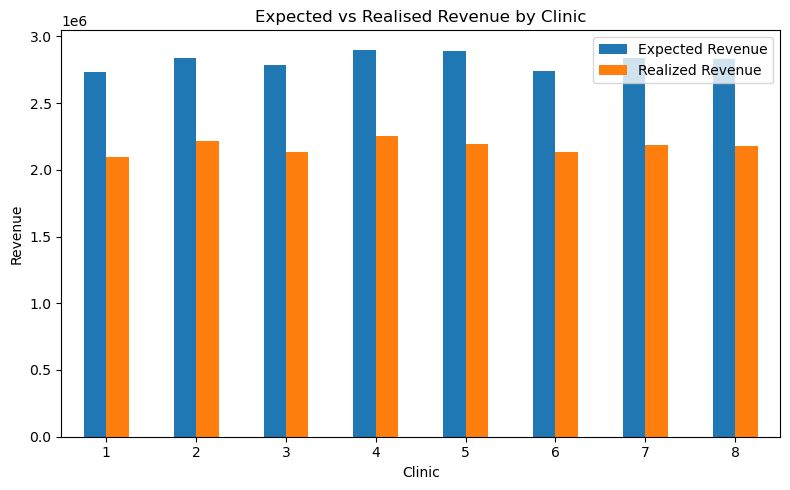

In [14]:
# 6. Revenue: expected vs. realized per clinic

clinic_rev = df.groupby("clinic_id")[["revenue_expected", "revenue_realized"]].sum()
clinic_rev["revenue_shortfall_pct"] = (1 -clinic_rev["revenue_realized"] /clinic_rev["revenue_expected"]) * 100

print(clinic_rev.to_string(formatters={ 'revenue_shortfall_pct': '{:.2f}%'.format}))
clinic_rev[["revenue_expected", "revenue_realized"]].plot(kind="bar",figsize=(8, 5))

plt.title("Expected vs Realised Revenue by Clinic")
plt.xlabel("Clinic")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.legend(["Expected Revenue", "Realized Revenue"])
plt.tight_layout()
plt.show()

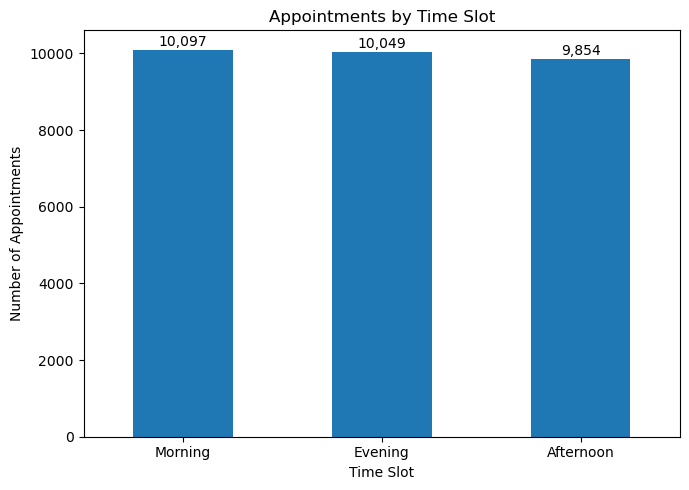

In [15]:
# 7. Appointments by time slot

counts = df["appointment_time_slot"].value_counts()

ax = counts.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Appointments by Time Slot")
plt.xlabel("Time Slot")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)

# Add counts above each bar
for i, count in enumerate(counts):
    ax.text(
        i,
        count + 100,
        f"{count:,}",
        ha="center"
    )

plt.tight_layout()
plt.show()

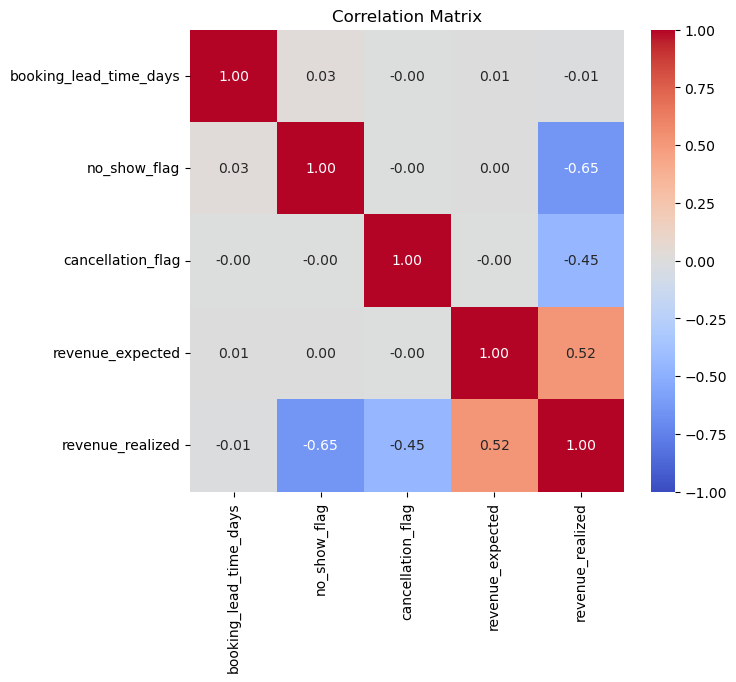

In [16]:
# 8. Correlation matrix of numeric variables
num_cols = ['booking_lead_time_days','no_show_flag','cancellation_flag',
            'revenue_expected','revenue_realized']
corr = df[num_cols].corr()

plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# # TASK 2: Machine learning models:Logistic Regression and Random Forest

In [17]:
# SCRIPT 1: LOGISTIC REGRESSION MODEL

import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


# Define features (X) and target (y)
# Target variable
y = df["no_show_flag"]

# 0 = Attended, 1 = No-show


# Predictor variables
X = df[["clinic_id","doctor_id","specialty","booking_lead_time_days","appointment_time_slot","revenue_expected"]]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

# Identify numerical and categorical variables
# Numerical variables
numeric_features = ["booking_lead_time_days","revenue_expected"]

# Categorical variables
categorical_features = ["clinic_id","specialty","appointment_time_slot"]

print("\n Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

# Train-Test Split (80% training, 20% testing with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.20,random_state=42,stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

# Preprocessing: One-Hot Encoding for categorical variables
try:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

preprocess = ColumnTransformer(
    transformers=[
        ('numerical', StandardScaler(), numeric_features),
        ('categorical', encoder, categorical_features)
    ]
)

# Create Logistic Regression pipeline
logistic_model = Pipeline([("preprocessing", preprocess),
    ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

# Train the model

logistic_model.fit(X_train,y_train)

print("\nLogistic Regression model trained successfully.")

# Generate predictions
y_pred_logistic = logistic_model.predict( X_test)

print("Predictions generated successfully.")
print("First 10 predictions:", y_pred_logistic[:10])

Features:
['clinic_id', 'doctor_id', 'specialty', 'booking_lead_time_days', 'appointment_time_slot', 'revenue_expected']

Target:
no_show_flag

 Numerical features: ['booking_lead_time_days', 'revenue_expected']
Categorical features: ['clinic_id', 'specialty', 'appointment_time_slot']
Training rows: 24000
Testing rows: 6000

Logistic Regression model trained successfully.
Predictions generated successfully.
First 10 predictions: [1 1 1 0 1 1 0 0 1 1]


In [18]:
# Script 2: Random Forest Classifier Model 
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#  Define features (X) and target (y)

y = df["no_show_flag"]

X = df[["clinic_id","specialty","booking_lead_time_days",
        "appointment_time_slot","revenue_expected"]]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

# Identify numerical and categorical variables
numeric_features = ["booking_lead_time_days","revenue_expected"]

categorical_features = ["clinic_id","specialty","appointment_time_slot"]

print("\nNumerical features:", numeric_features)
print("Categorical features:", categorical_features)


# 3. Train-test split (80/20)

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.20,random_state=42,stratify=y
)

print("\nTraining rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

# Preprocessing: One-Hot Encoding for categorical variables

try:
    encoder = OneHotEncoder(handle_unknown="ignore",drop="first",sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore",drop="first",sparse=False)

# Create preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("numerical","passthrough",numeric_features),
        ("categorical", encoder, categorical_features)
    ]
)

#  Create Random Forest pipeline

random_forest_model = Pipeline(steps=[("preprocessing", preprocess),
        ( "model",RandomForestClassifier(n_estimators=200,random_state=42,
                class_weight="balanced",n_jobs=-1))]
)

#  Train the model

print("\n--- Training Random Forest Model ---")
random_forest_model.fit(X_train, y_train)

#  Generate predictions

y_pred_rf = random_forest_model.predict(X_test)
print("Random Forest training and prediction complete.")

Features:
['clinic_id', 'specialty', 'booking_lead_time_days', 'appointment_time_slot', 'revenue_expected']

Target:
no_show_flag

Numerical features: ['booking_lead_time_days', 'revenue_expected']
Categorical features: ['clinic_id', 'specialty', 'appointment_time_slot']

Training rows: 24000
Testing rows: 6000

--- Training Random Forest Model ---
Random Forest training and prediction complete.


# TASK 3: MODEL EVALUATION, VISUALISATION AND COMPARISON


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Store predictions from Task 2
models = {
    'Logistic Regression': y_pred_logistic,
    'Random Forest': y_pred_rf
}

# Compute metrics for both models
results = []

def evaluate_model(name, y_test, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1-score': f1_score(y_test, y_pred, zero_division=0)
    }

results = pd.DataFrame([
    evaluate_model('Logistic Regression',y_test,y_pred_logistic),
    evaluate_model('Random Forest',y_test,y_pred_rf)
])

results.round(3)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.526,0.169,0.502,0.253
1,Random Forest,0.808,0.163,0.048,0.074


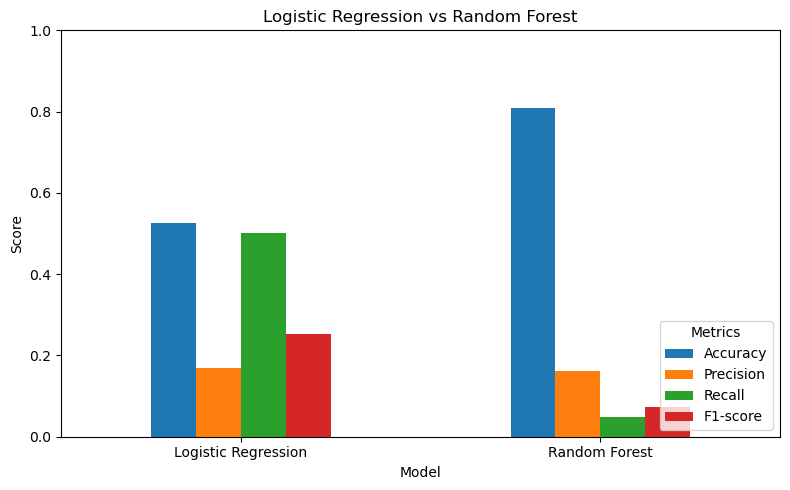

In [20]:
# Model comparison
results.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-score']].plot(kind='bar',figsize=(8, 5))

plt.title('Logistic Regression vs Random Forest')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Metrics',loc='lower right')
plt.tight_layout()
plt.show()

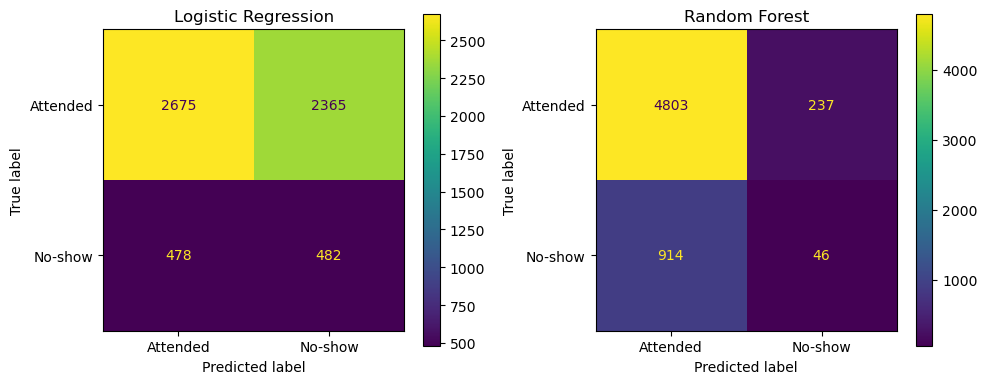

In [21]:
# Confusion Matrices

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

models = [
    ('Logistic Regression', y_pred_logistic),
    ('Random Forest', y_pred_rf)
]

for ax, (name, pred) in zip(axes, models):
    ConfusionMatrixDisplay.from_predictions(y_test, pred,display_labels=['Attended', 'No-show'],values_format='d',ax=ax )
    ax.set_title(name)

plt.tight_layout()
plt.show()


ROC-AUC Scores:
Logistic Regression: 0.52
Random Forest: 0.496


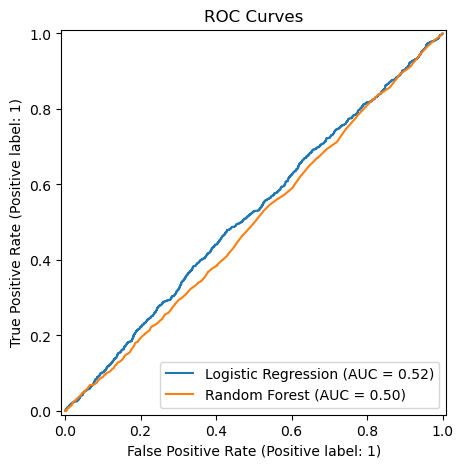

In [22]:
# ROC-AUC curve
from sklearn.metrics import RocCurveDisplay, roc_auc_score

auc_logistic = roc_auc_score(
    y_test,
    logistic_model.predict_proba(X_test)[:, 1]
)

auc_rf = roc_auc_score(
    y_test,
    random_forest_model.predict_proba(X_test)[:, 1]
)

print("ROC-AUC Scores:")
print("Logistic Regression:", round(auc_logistic, 3))
print("Random Forest:", round(auc_rf, 3))

plt.figure(figsize=(7,5))
for name, model in [('Logistic Regression', logistic_model),('Random Forest', random_forest_model) ]:
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=plt.gca())
plt.title('ROC Curves')
plt.show()